In [19]:
import pandas as pd
import numpy as np
import xarray as xr

c:\Users\5982758\AppData\Local\anaconda3\envs\prisma-summer\Lib\site-packages\ema_workbench\__init__.py:42: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  from . import em_framework, util


2.4.6
c:\Users\5982758\AppData\Local\anaconda3\envs\prisma-summer\Lib\site-packages\numpy\__init__.py
True


In [20]:
# Load the CSV file with time series data
df = pd.read_csv(r"raw\SCI-2025_v1.0_pathways_ensemble_global.csv", 
                 encoding='latin1', sep=';')
print(f"Loaded data: {df.shape[0]:,} rows, {df['Scenario'].nunique()} scenarios")

Loaded data: 548,541 rows, 666 scenarios


In [45]:
# Convert to long format
time_cols = [col for col in df.columns if col.isdigit()]
df_melted = df.melt(
    id_vars=['Model', 'Scenario', 'Region', 'Variable', 'Unit'],
    value_vars=time_cols,
    var_name='Year',
    value_name='Value'
)
df_melted['Year'] = df_melted['Year'].astype(int)

df_melted.head(10)

,Model,Scenario,Region,Variable,Unit,Year,Value
0,AIM/CGE 2.0,SSP1-19,World,Agricultural Demand|Crops,million t DM/yr,2010,3489.8126
1,AIM/CGE 2.0,SSP1-19,World,Agricultural Demand|Livestock,million t DM/yr,2010,195.2943
2,AIM/CGE 2.0,SSP1-19,World,Agricultural Production|Crops|Energy Crops,million t DM/yr,2010,0.0000
3,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity,GW,2010,4164.7229
4,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Biomass,GW,2010,61.5660
5,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Coal,GW,2010,1617.1939
6,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Fossil,GW,2010,2532.2525
7,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Gas,GW,2010,693.6514
8,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Geothermal,GW,2010,9.2150
9,AIM/CGE 2.0,SSP1-19,World,Capacity|Electricity|Hydro,GW,2010,967.7712


In [22]:
# Create xarray DataArray
df_melted['scenario_id'] = df_melted['Model'] + ' | ' + df_melted['Scenario']
df_melted = df_melted.drop_duplicates(subset=['scenario_id', 'Variable', 'Year'], keep='first')

df_indexed = df_melted.set_index(['scenario_id', 'Variable', 'Year'])
da = df_indexed['Value'].to_xarray()
print(f"XArray created: {da.dims}")
da

XArray created: ('scenario_id', 'Variable', 'Year')


<xarray.DataArray 'Value' (scenario_id: 1599, Variable: 2158, Year: 19)> Size: 524MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [3489.8126 , 3711.0672 , 3932.3218 , ..., 4703.03   ,
                nan, 4439.7738 ],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [3489.8105 , 3711.08855, 3932.3666 , ..., 4787.2616 ,
                nan, 4523.527  ],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(1599, 2158, 19))
Coordinates:
  * scenario_id  (scenario_id) object 13kB 'AIM/CGE 2.0 | SSP1-19' ... 'WITCH...
  * Variable     (Variable) object 17kB 'Agricultural Demand' ... 'Yield|Crop...
  * Year         (Year) int64 152B 2010 2015 2020 2025 ... 2085 2090 2095 2100

In [100]:
df_melted['Variable'].unique()

<StringArray>
[                                 'Agricultural Demand|Crops',
                              'Agricultural Demand|Livestock',
                 'Agricultural Production|Crops|Energy Crops',
                                       'Capacity|Electricity',
                               'Capacity|Electricity|Biomass',
                                  'Capacity|Electricity|Coal',
                                'Capacity|Electricity|Fossil',
                                   'Capacity|Electricity|Gas',
                            'Capacity|Electricity|Geothermal',
                                 'Capacity|Electricity|Hydro',
 ...
                             'Capital Cost|Gases|Coal|w/ CCS',
                       'Final Energy|Commercial|Gases|Fossil',
                           'Final Energy|Industry|Geothermal',
        'Final Energy|Transportation|Domestic Shipping|Gases',
 'Final Energy|Transportation|Domestic Shipping|Gases|Fossil',
                     'Final Energy|T

In [23]:
# Split scenarios by net zero in 2070
co2_2070 = da.sel(Variable='Emissions|CO2', Year=2070)
net_zero_mask = (co2_2070 <= 0) & ~np.isnan(co2_2070)

# Get scenario IDs for each group
net_zero_scenarios = co2_2070.scenario_id[net_zero_mask.values].values
not_net_zero_scenarios = co2_2070.scenario_id[(~net_zero_mask & ~np.isnan(co2_2070)).values].values

da_net_zero = da.sel(scenario_id=net_zero_scenarios)
da_not_net_zero = da.sel(scenario_id=not_net_zero_scenarios)

print(f"Net zero scenarios: {len(net_zero_scenarios)}")
print(f"Non-net zero scenarios: {len(not_net_zero_scenarios)}")

IndexError: dimension coordinate 'Variable' conflicts between indexed and indexing objects:
<xarray.DataArray 'Variable' (Variable: 2158)> Size: 17kB
array(['Agricultural Demand', 'Agricultural Demand|Crops',
       'Agricultural Demand|Crops|Bioenergy', ..., 'Yield|Cropland|Cereals',
       'Yield|Cropland|Oil Crops', 'Yield|Cropland|Sugar Crops'],
      shape=(2158,), dtype=object)
Coordinates:
  * Variable  (Variable) object 17kB 'Agricultural Demand' ... 'Yield|Croplan...
vs.
<xarray.Variable ()> Size: 52B
array('Emissions|CO2', dtype='<U13')

In [104]:
# Analyze variable coverage at a specific year
year_for_coverage = 2030

# Get all available variables
all_variables = da.coords['Variable'].values.tolist()

# Calculate coverage for each variable
coverage_data = []
for var in all_variables:
    try:
        var_data = da.sel(Variable=var, Year=year_for_coverage).values
        coverage = (~np.isnan(var_data)).sum() / len(var_data)
        num_scenarios = (~np.isnan(var_data)).sum()
        coverage_data.append({
            'Variable': var,
            'Coverage': coverage,
            'Num_Scenarios': num_scenarios,
            'Total_Scenarios': len(var_data)
        })
    except:
        pass

# Create DataFrame and sort by coverage
coverage_df = pd.DataFrame(coverage_data)
coverage_df = coverage_df.sort_values('Coverage', ascending=False)

print(f"Variable Coverage Analysis at Year {year_for_coverage}")
print("="*100)
print(f"Total variables: {len(coverage_df)}")
print(f"\nTop 30 variables by coverage:")
print(coverage_df.head(200).to_string(index=False))
print(f"\n\nCoverage statistics:")
print(f"  Mean coverage: {coverage_df['Coverage'].mean():.1%}")
print(f"  Median coverage: {coverage_df['Coverage'].median():.1%}")
print(f"  Variables with ≥30% coverage: {(coverage_df['Coverage'] >= 0.3).sum()}")
print(f"  Variables with ≥50% coverage: {(coverage_df['Coverage'] >= 0.5).sum()}")
print(f"  Variables with 100% coverage: {(coverage_df['Coverage'] == 1.0).sum()}")

Variable Coverage Analysis at Year 2030
Total variables: 2158

Top 30 variables by coverage:
                                                                        Variable  Coverage  Num_Scenarios  Total_Scenarios
                                   Emissions|CO2|Energy and Industrial Processes  0.994997           1591             1599
                                                                   Emissions|CO2  0.990619           1584             1599
                                                              Primary Energy|Gas  0.989994           1583             1599
                                                              Primary Energy|Oil  0.989994           1583             1599
                                                          Primary Energy|Nuclear  0.989994           1583             1599
                                                             Primary Energy|Coal  0.989994           1583             1599
                                              

## CART Analysis

Build a Classification and Regression Tree to identify which factors distinguish net zero scenarios from non-net zero scenarios.

In [105]:
# Prepare data for CART analysis
# Use specific variables selected for analysis
year_to_analyze = 2030

# Define variables of interest
variables_of_interest = [
    'Emissions|CO2',
    'Primary Energy|Fossil',
    'Primary Energy|Biomass',
    'Primary Energy|Non-Biomass Renewables',
    'Carbon Capture|Geological Storage|Biomass',
    'Final Energy|Electricity',
    'Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]'
]

print(f"Analyzing {len(variables_of_interest)} selected variables:")
for var in variables_of_interest:
    print(f"  - {var}")

# Extract data for selected variables at the specified year
data_for_cart = []
variables_with_data = []
for var in variables_of_interest:
    try:
        var_data = da.sel(Variable=var, Year=year_to_analyze).values
        coverage = (~np.isnan(var_data)).sum() / len(var_data)
        data_for_cart.append(var_data)
        variables_with_data.append(var)
        print(f"  ✓ {var}: {coverage:.1%} coverage")
    except Exception as e:
        print(f"  ✗ {var}: Not available - {str(e)}")

print(f"\nSuccessfully loaded {len(variables_with_data)} variables")

# Create DataFrame for CART input
x = pd.DataFrame(np.column_stack(data_for_cart), columns=variables_with_data)

# Add Model Family and Scenario information
scenario_ids = da.coords['scenario_id'].values
model_names = [sid.split(' | ')[0] for sid in scenario_ids]
scenario_names = [sid.split(' | ')[1] for sid in scenario_ids]

# Aggregate models to families
def get_model_family(model_name):
    if 'REMIND' in model_name:
        return 'REMIND'
    elif 'MESSAGEix' in model_name or 'MESSAGE' in model_name:
        return 'MESSAGEix'
    elif 'IMAGE' in model_name:
        return 'IMAGE'
    elif 'WITCH' in model_name:
        return 'WITCH'
    elif 'GCAM' in model_name:
        return 'GCAM'
    elif 'AIM' in model_name:
        return 'AIM'
    elif 'POLES' in model_name:
        return 'POLES'
    elif 'IMACLIM' in model_name:
        return 'IMACLIM'
    else:
        return model_name.split()[0]

x['Model_Family'] = [get_model_family(m) for m in model_names]
x['Scenario'] = scenario_names

# Binary outcome: net zero by 2070
y = net_zero_mask.values

# Remove rows that have NaN in outcome or have too many missing values
# Keep rows with at least 50% of variables populated
nan_count_threshold = 0.5 * len(variables_with_data)
valid_rows = (x[variables_with_data].notna().sum(axis=1) >= nan_count_threshold) & ~np.isnan(y)
x = x[valid_rows]
y = y[valid_rows]

# For remaining NaNs, fill with median values
for col in variables_with_data:
    if x[col].isna().any():
        median_val = x[col].median()
        if np.isnan(median_val):
            median_val = 0
        x[col].fillna(median_val, inplace=True)

print(f"\nCART data prepared: {x.shape[0]} scenarios, {x.shape[1]} variables (including Model_Family & Scenario)")
print(f"Net zero scenarios: {y.sum()}, Non-net zero: {(~y).sum()}")
print(f"Unique model families: {x['Model_Family'].nunique()}, Unique scenario families: {x['Scenario'].nunique()}")

Analyzing 7 selected variables:
  - Emissions|CO2
  - Primary Energy|Fossil
  - Primary Energy|Biomass
  - Primary Energy|Non-Biomass Renewables
  - Carbon Capture|Geological Storage|Biomass
  - Final Energy|Electricity
  - Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]
  ✓ Emissions|CO2: 99.1% coverage
  ✓ Primary Energy|Fossil: 98.5% coverage
  ✓ Primary Energy|Biomass: 98.7% coverage
  ✓ Primary Energy|Non-Biomass Renewables: 91.3% coverage
  ✓ Carbon Capture|Geological Storage|Biomass: 91.1% coverage
  ✓ Final Energy|Electricity: 97.4% coverage
  ✓ Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]: 96.4% coverage

Successfully loaded 7 variables

CART data prepared: 1581 scenarios, 9 variables (including Model_Family & Scenario)
Net zero scenarios: 476, Non-net zero: 1105
Unique model families: 14, Unique scenario families: 658


C:\Users\5982758\AppData\Local\Temp\ipykernel_20520\3068418759.py:83: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x[col].fillna(median_val, inplace=True)
C:\Users\5982758\AppData\Local\Temp\ipykernel_20520\3068418759.py:83: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

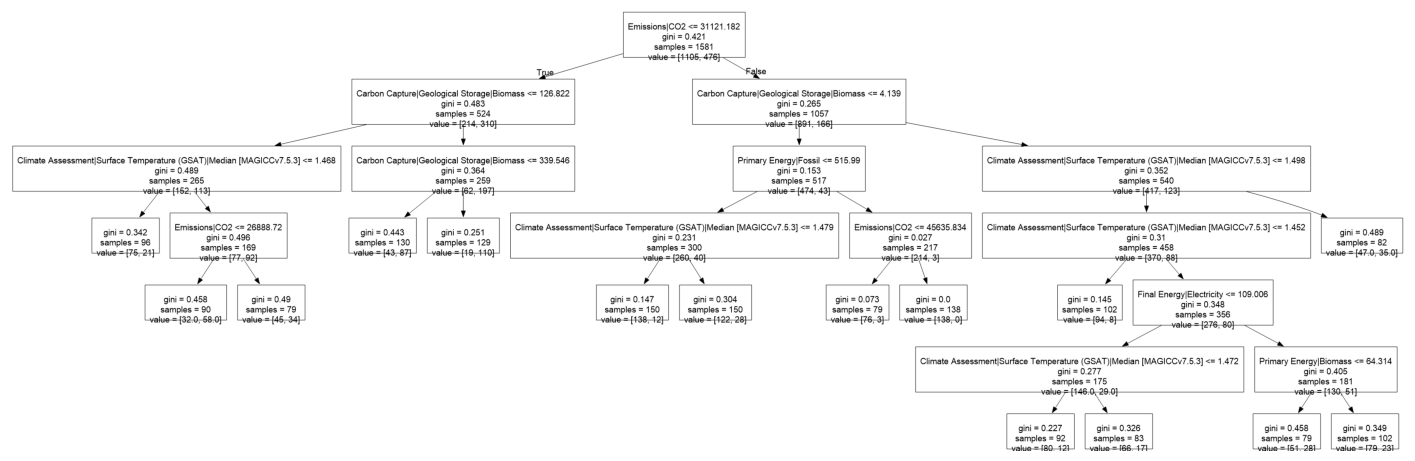

In [106]:
# Build and visualize CART tree
import matplotlib.pyplot as plt
from ema_workbench.analysis import cart

cart_alg = cart.CART(x, y)
cart_alg.build_tree()

fig = cart_alg.show_tree()
fig.set_size_inches((18, 12))
plt.show()

In [107]:
# Extract variables used by CART for splits
# CART uses sklearn DecisionTreeClassifier internally
cart_tree = cart_alg.clf.tree_
feature_indices = set()

# Get indices of features that were used in the tree (feature != -2 means it was used)
for i in range(cart_tree.node_count):
    if cart_tree.feature[i] != -2:  # -2 indicates a leaf node
        feature_indices.add(cart_tree.feature[i])

# Get the actual feature names from the indices
cart_variables = [x.columns[i] for i in sorted(feature_indices) if i < len(x.columns)]

# Remove Model_Family and Scenario if they somehow got included
cart_variables = [v for v in cart_variables if v not in ['Model_Family', 'Scenario']]

print(f"CART identified {len(cart_variables)} important variables for splits:")
for var in cart_variables:
    print(f"  - {var}")

# Create filtered dataset with only CART variables plus Model_Family and Scenario for context
x_cart = x[cart_variables + ['Model_Family', 'Scenario']].copy()
print(f"\nFiltered dataset for PRIM: {x_cart.shape[0]} scenarios, {x_cart.shape[1]} columns")

CART identified 6 important variables for splits:
  - Emissions|CO2
  - Primary Energy|Fossil
  - Primary Energy|Biomass
  - Carbon Capture|Geological Storage|Biomass
  - Final Energy|Electricity
  - Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]

Filtered dataset for PRIM: 1581 scenarios, 8 columns


## PRIM Analysis

Patient Rule Induction Method (PRIM) finds regions in the input space with high coverage and density of cases of interest (net zero scenarios).

In [108]:
# Run PRIM to find boxes of interest (using CART-filtered variables)
from ema_workbench.analysis import prim

prim_alg = prim.Prim(x_cart, y)
box1 = prim_alg.find_box()

print(f"PRIM analysis complete. Found box with {len(box1.peeling_trajectory)} peeling steps.")

PRIM analysis complete. Found box with 408 peeling steps.


In [85]:
box2 = prim_alg.find_box()

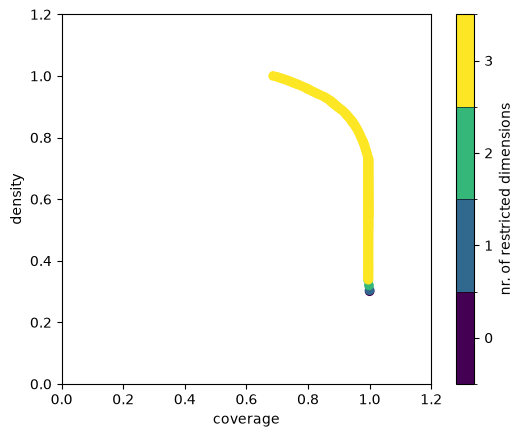

In [109]:
# Visualize tradeoff between coverage and density
box1.show_tradeoff()
plt.show()

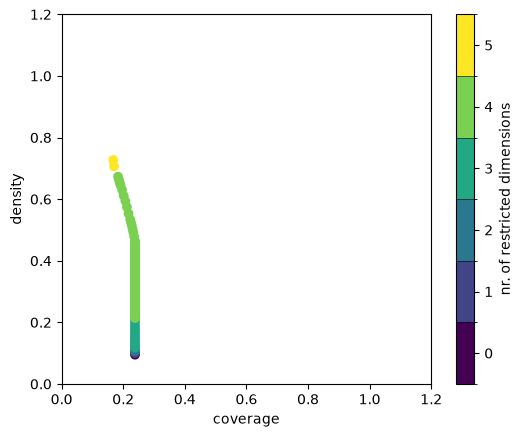

In [87]:
box2.show_tradeoff()
plt.show()

In [110]:
# Inspect the tradeoff table
box1.inspect_tradeoff()

MaxRowsError: The number of rows in your dataset (189313) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.VConcatChart(...)

In [75]:
# Select a specific box from the tradeoff (adjust this based on the tradeoff table above)
selected_box = 6  # Change this to select different boxes

In [89]:
# Inspect the selected box (text format)
box1.inspect(selected_box)

coverage      1.000000
density       0.418401
id            6.000000
k           382.000000
mass          0.730985
mean          0.418401
n           913.000000
res_dim       1.000000
Name: 6, dtype: float64

                     box 6                                    
                       min          max qp value      qp value
Emissions|CO2 -8000.007366  31458.26165      NaN  4.405759e-13



[None]

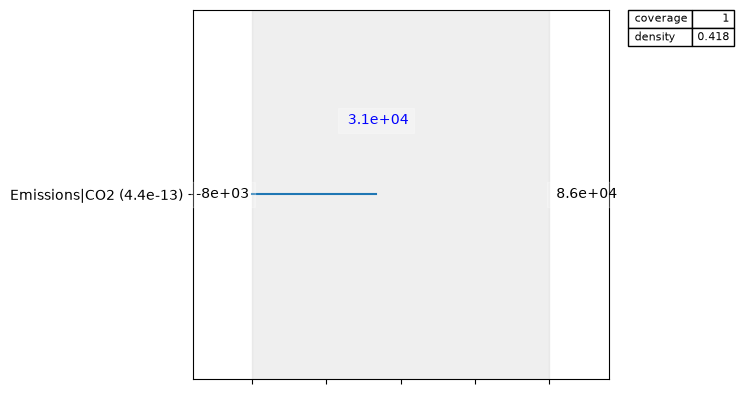

In [90]:
# Inspect the selected box (graphical format)
box1.inspect(selected_box, style='graph')
plt.show()

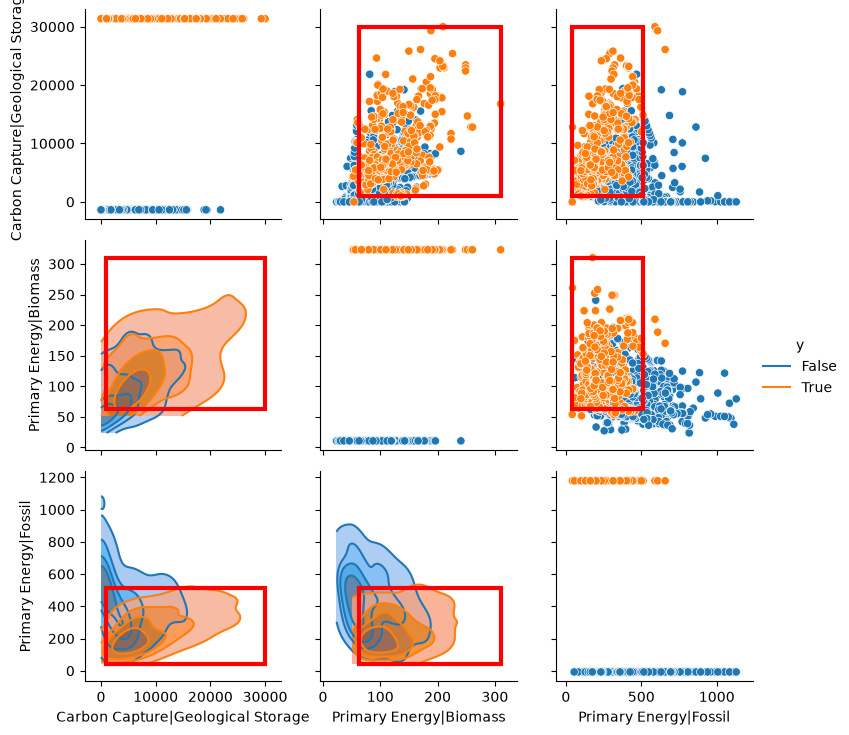

In [42]:
# Visualize box with pairwise scatter plots
box1.show_pairs_scatter(selected_box)
plt.show()

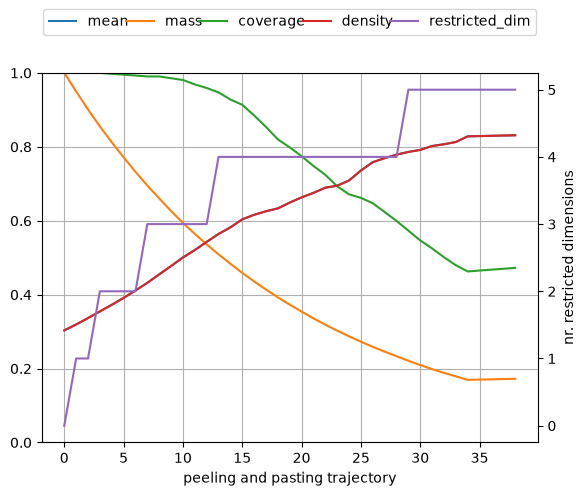

In [33]:
# Visualize individual boxes on the tradeoff trajectory
box1.show_ppt()
plt.show()

In [49]:
# Analyze which models and scenarios achieve net zero in the selected box
# Get scenarios in the selected box
box_lim = box1.box_lims[selected_box]
in_box = np.ones(len(x_cart), dtype=bool)

# Apply all box constraints
for var_name, (lower, upper) in box_lim.items():
    if var_name in x_cart.columns:
        in_box &= (x_cart[var_name] >= lower) & (x_cart[var_name] <= upper)

# Create analysis dataframe
box_analysis = pd.DataFrame({
    'Model_Family': x_cart['Model_Family'],
    'Scenario': x_cart['Scenario'],
    'Net Zero': y,
    'In Box': in_box
})

# Summary by model family for scenarios in the box
box_scenarios = box_analysis[box_analysis['In Box']]
model_summary = box_scenarios.groupby('Model_Family').agg({
    'Net Zero': ['sum', 'count']
}).reset_index()
model_summary.columns = ['Model_Family', 'Net Zero Count', 'Total Count']
model_summary['Net Zero Rate'] = model_summary['Net Zero Count'] / model_summary['Total Count']
model_summary = model_summary.sort_values('Net Zero Rate', ascending=False)

print(f"Scenarios in selected box: {in_box.sum()} (Net Zero: {(in_box & y).sum()}, Non-Net Zero: {(in_box & ~y).sum()})")
print(f"\nModel families by net zero rate in the box:")
print(model_summary.to_string(index=False))

Scenarios in selected box: 1007 (Net Zero: 414, Non-Net Zero: 593)

Top 10 models by net zero rate in the box:
                           Model  Net Zero Count  Total Count  Net Zero Rate
                        GCAM 5.2               1            1       1.000000
                     POLES EMF30               2            2       1.000000
                  POLES GECO2019               4            4       1.000000
                      REMIND 3.5               1            1       1.000000
            REMIND-Buildings 2.0               2            2       1.000000
       MESSAGEix-GLOBIOM GEI 1.0              14           14       1.000000
MESSAGEix-GLOBIOM 2.0-M-R12-NGFS               1            1       1.000000
           REMIND-MAgPIE 3.2-4.6               9           10       0.900000
           MESSAGEix-GLOBIOM 1.0               4            5       0.800000
                      REMIND 1.7              11           14       0.785714


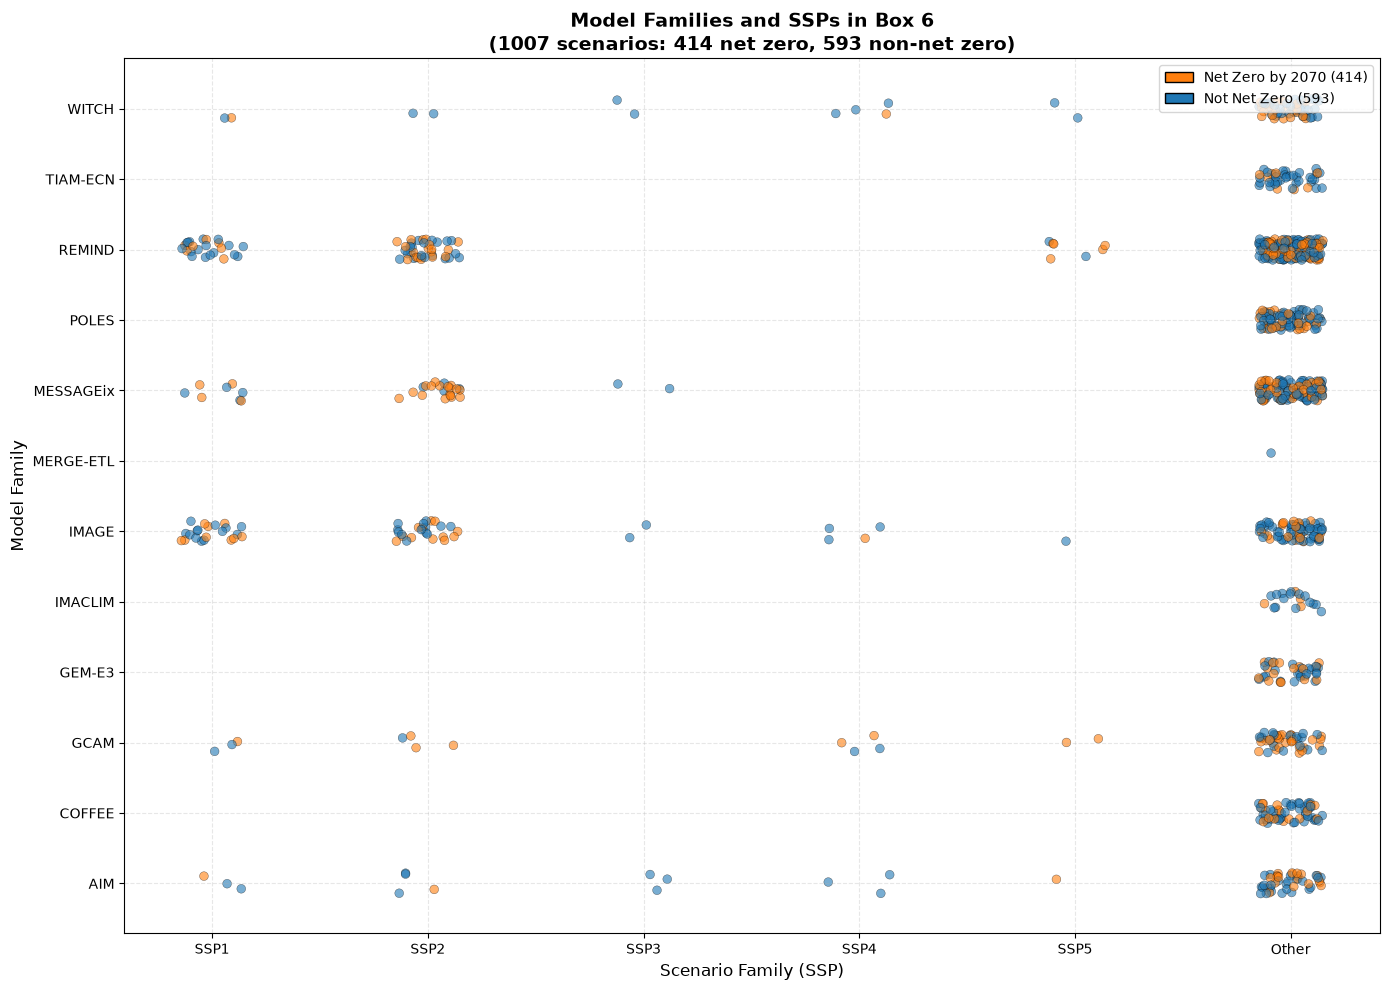

In [55]:
# Create scatter plot showing models and scenarios in the box
fig, ax = plt.subplots(figsize=(14, 10))

# Filter to only scenarios in the box
box_data = box_analysis[box_analysis['In Box']].copy()

# Extract SSP from scenario name
def get_ssp(scenario_name):
    scenario_upper = scenario_name.upper()
    for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
        if ssp in scenario_upper:
            return ssp
    return 'Other'

box_data['SSP'] = box_data['Scenario'].apply(get_ssp)

# Create numeric encoding for axes
unique_ssps = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5', 'Other']
ssp_to_num = {ssp: i for i, ssp in enumerate(unique_ssps) if ssp in box_data['SSP'].values}
unique_families = sorted(box_data['Model_Family'].unique())
family_to_num = {family: i for i, family in enumerate(unique_families)}

box_data['SSP_Num'] = box_data['SSP'].map(ssp_to_num)
box_data['Family_Num'] = box_data['Model_Family'].map(family_to_num)

# Add jitter to avoid overlapping points
np.random.seed(42)  # For reproducibility
jitter_amount = 0.15
box_data['SSP_Jitter'] = box_data['SSP_Num'] + np.random.uniform(-jitter_amount, jitter_amount, len(box_data))
box_data['Family_Jitter'] = box_data['Family_Num'] + np.random.uniform(-jitter_amount, jitter_amount, len(box_data))

# Plot points colored by net zero status
colors = ['#ff7f0e' if nz else '#1f77b4' for nz in box_data['Net Zero']]
ax.scatter(box_data['SSP_Jitter'], box_data['Family_Jitter'], 
           c=colors, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)

# Customize plot
ax.set_xlabel('Scenario Family (SSP)', fontsize=12)
ax.set_ylabel('Model Family', fontsize=12)
ax.set_xticks(list(ssp_to_num.values()))
ax.set_xticklabels([ssp for ssp in unique_ssps if ssp in ssp_to_num.keys()], fontsize=10)
ax.set_yticks(list(family_to_num.values()))
ax.set_yticklabels(unique_families, fontsize=10)
ax.set_title(f'Model Families and SSPs in Box {selected_box}\n({in_box.sum()} scenarios: {(in_box & y).sum()} net zero, {(in_box & ~y).sum()} non-net zero)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff7f0e', edgecolor='black', label=f'Net Zero by 2070 ({(in_box & y).sum()})'),
    Patch(facecolor='#1f77b4', edgecolor='black', label=f'Not Net Zero ({(in_box & ~y).sum()})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [56]:
# Analyze the "Other" scenarios (non-SSP)
other_scenarios = box_data[box_data['SSP'] == 'Other'].copy()

print(f"Total 'Other' scenarios in box: {len(other_scenarios)}")
print(f"Net zero: {other_scenarios['Net Zero'].sum()}, Non-net zero: {(~other_scenarios['Net Zero']).sum()}")
print(f"\nUnique scenario names in 'Other' category: {other_scenarios['Scenario'].nunique()}")
print("\n" + "="*80)
print("Sample of 'Other' scenario names (first 30 unique):")
print("="*80)
for i, scenario in enumerate(other_scenarios['Scenario'].unique()[:30], 1):
    print(f"{i:2d}. {scenario}")

Total 'Other' scenarios in box: 812
Net zero: 327, Non-net zero: 485

Unique scenario names in 'Other' category: 325

Sample of 'Other' scenario names (first 30 unique):
 1. CD-LINKS-INDC2030i_1600
 2. CD-LINKS-INDCi
 3. CD-LINKS-NDC2030i_1000
 4. CD-LINKS-NPi2020_1000
 5. CD-LINKS-NPi2020_1600
 6. CD-LINKS-NPi2020_400
 7. COMMIT-Bridge
 8. ENGAGE-INDCi2030-1000f
 9. ENGAGE-INDCi2030-1200
10. ENGAGE-INDCi2030-1200f
11. ENGAGE-INDCi2030-1400
12. ENGAGE-INDCi2030-1400f
13. ENGAGE-INDCi2030-1600
14. ENGAGE-INDCi2030-1600f
15. ENGAGE-INDCi2030-1800
16. ENGAGE-INDCi2030-1800f
17. ENGAGE-INDCi2030-800f
18. ENGAGE-INDCi2030-900f
19. ENGAGE-INDCi2100
20. ENGAGE-NPi2020-1000
21. ENGAGE-NPi2020-1000f
22. ENGAGE-NPi2020-1200
23. ENGAGE-NPi2020-1200f
24. ENGAGE-NPi2020-1400
25. ENGAGE-NPi2020-1400f
26. ENGAGE-NPi2020-1600
27. ENGAGE-NPi2020-1600f
28. ENGAGE-NPi2020-1800
29. ENGAGE-NPi2020-1800f
30. ENGAGE-NPi2020-300f


In [57]:
# Categorize 'Other' scenarios by project/family
def categorize_other_scenarios(scenario_name):
    if 'CD-LINKS' in scenario_name:
        return 'CD-LINKS'
    elif 'ENGAGE' in scenario_name:
        return 'ENGAGE'
    elif 'COMMIT' in scenario_name:
        return 'COMMIT'
    elif 'ADVANCE' in scenario_name:
        return 'ADVANCE'
    elif 'EMF' in scenario_name:
        return 'EMF'
    elif 'NGFS' in scenario_name:
        return 'NGFS'
    elif 'CRESCENDO' in scenario_name:
        return 'CRESCENDO'
    else:
        return 'Other Project'

other_scenarios['Project'] = other_scenarios['Scenario'].apply(categorize_other_scenarios)

# Summary statistics by project
project_summary = other_scenarios.groupby('Project').agg({
    'Net Zero': ['sum', 'count']
}).reset_index()
project_summary.columns = ['Project', 'Net Zero Count', 'Total Count']
project_summary['Net Zero Rate'] = project_summary['Net Zero Count'] / project_summary['Total Count']
project_summary = project_summary.sort_values('Total Count', ascending=False)

print("\nScenario Projects in 'Other' category:")
print("="*80)
print(project_summary.to_string(index=False))


Scenario Projects in 'Other' category:
      Project  Net Zero Count  Total Count  Net Zero Rate
       ENGAGE             153          447       0.342282
Other Project              90          171       0.526316
          EMF              21           80       0.262500
         NGFS              19           33       0.575758
      ADVANCE              16           30       0.533333
     CD-LINKS              15           28       0.535714
       COMMIT              13           23       0.565217


### Analysis of ALL Scenarios (not just Box 6)

In [67]:
# Analyze all scenarios in the dataset
all_data = pd.DataFrame({
    'Model_Family': x['Model_Family'],
    'Scenario': x['Scenario'],
    'Net Zero': y
})

# Extract SSP from scenario name
def get_ssp(scenario_name):
    scenario_upper = scenario_name.upper()
    for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
        if ssp in scenario_upper:
            return ssp
    return 'Other'

all_data['SSP'] = all_data['Scenario'].apply(get_ssp)

# Summary by SSP
ssp_summary = all_data.groupby('SSP').agg({
    'Net Zero': ['sum', 'count']
}).reset_index()
ssp_summary.columns = ['SSP', 'Net Zero Count', 'Total Count']
ssp_summary['Net Zero Rate'] = ssp_summary['Net Zero Count'] / ssp_summary['Total Count']
ssp_summary = ssp_summary.sort_values('Total Count', ascending=False)

print("="*80)
print("SSP Distribution in ALL Scenarios")
print("="*80)
print(ssp_summary.to_string(index=False))
print(f"\nTotal scenarios: {len(all_data)}")
print(f"Total net zero: {all_data['Net Zero'].sum()} ({100*all_data['Net Zero'].sum()/len(all_data):.1f}%)")

SSP Distribution in ALL Scenarios
  SSP  Net Zero Count  Total Count  Net Zero Rate
Other             299         1011       0.295747
 SSP2              51          125       0.408000
 SSP1              21           66       0.318182
 SSP5               8           32       0.250000
 SSP4               3           12       0.250000
 SSP3               0            3       0.000000

Total scenarios: 1249
Total net zero: 382 (30.6%)


In [68]:
# Analyze the "Other" scenarios (non-SSP) in ALL scenarios
all_other_scenarios = all_data[all_data['SSP'] == 'Other'].copy()

# Categorize by project
def categorize_other_scenarios(scenario_name):
    if 'CD-LINKS' in scenario_name:
        return 'CD-LINKS'
    elif 'ENGAGE' in scenario_name:
        return 'ENGAGE'
    elif 'COMMIT' in scenario_name:
        return 'COMMIT'
    elif 'ADVANCE' in scenario_name:
        return 'ADVANCE'
    elif 'EMF' in scenario_name:
        return 'EMF'
    elif 'NGFS' in scenario_name:
        return 'NGFS'
    elif 'CRESCENDO' in scenario_name:
        return 'CRESCENDO'
    else:
        return 'Other Project'

all_other_scenarios['Project'] = all_other_scenarios['Scenario'].apply(categorize_other_scenarios)

# Summary statistics by project
all_project_summary = all_other_scenarios.groupby('Project').agg({
    'Net Zero': ['sum', 'count']
}).reset_index()
all_project_summary.columns = ['Project', 'Net Zero Count', 'Total Count']
all_project_summary['Net Zero Rate'] = all_project_summary['Net Zero Count'] / all_project_summary['Total Count']
all_project_summary = all_project_summary.sort_values('Total Count', ascending=False)

print("\n" + "="*80)
print("Scenario Projects in 'Other' category (ALL scenarios)")
print("="*80)
print(all_project_summary.to_string(index=False))
print(f"\nTotal 'Other' scenarios: {len(all_other_scenarios)}")
print(f"Net zero in 'Other': {all_other_scenarios['Net Zero'].sum()} ({100*all_other_scenarios['Net Zero'].sum()/len(all_other_scenarios):.1f}%)")


Scenario Projects in 'Other' category (ALL scenarios)
      Project  Net Zero Count  Total Count  Net Zero Rate
       ENGAGE             153          603       0.253731
Other Project              94          207       0.454106
          EMF               4           78       0.051282
         NGFS              20           47       0.425532
       COMMIT              13           41       0.317073
      ADVANCE              11           26       0.423077
     CD-LINKS               4            9       0.444444

Total 'Other' scenarios: 1011
Net zero in 'Other': 299 (29.6%)


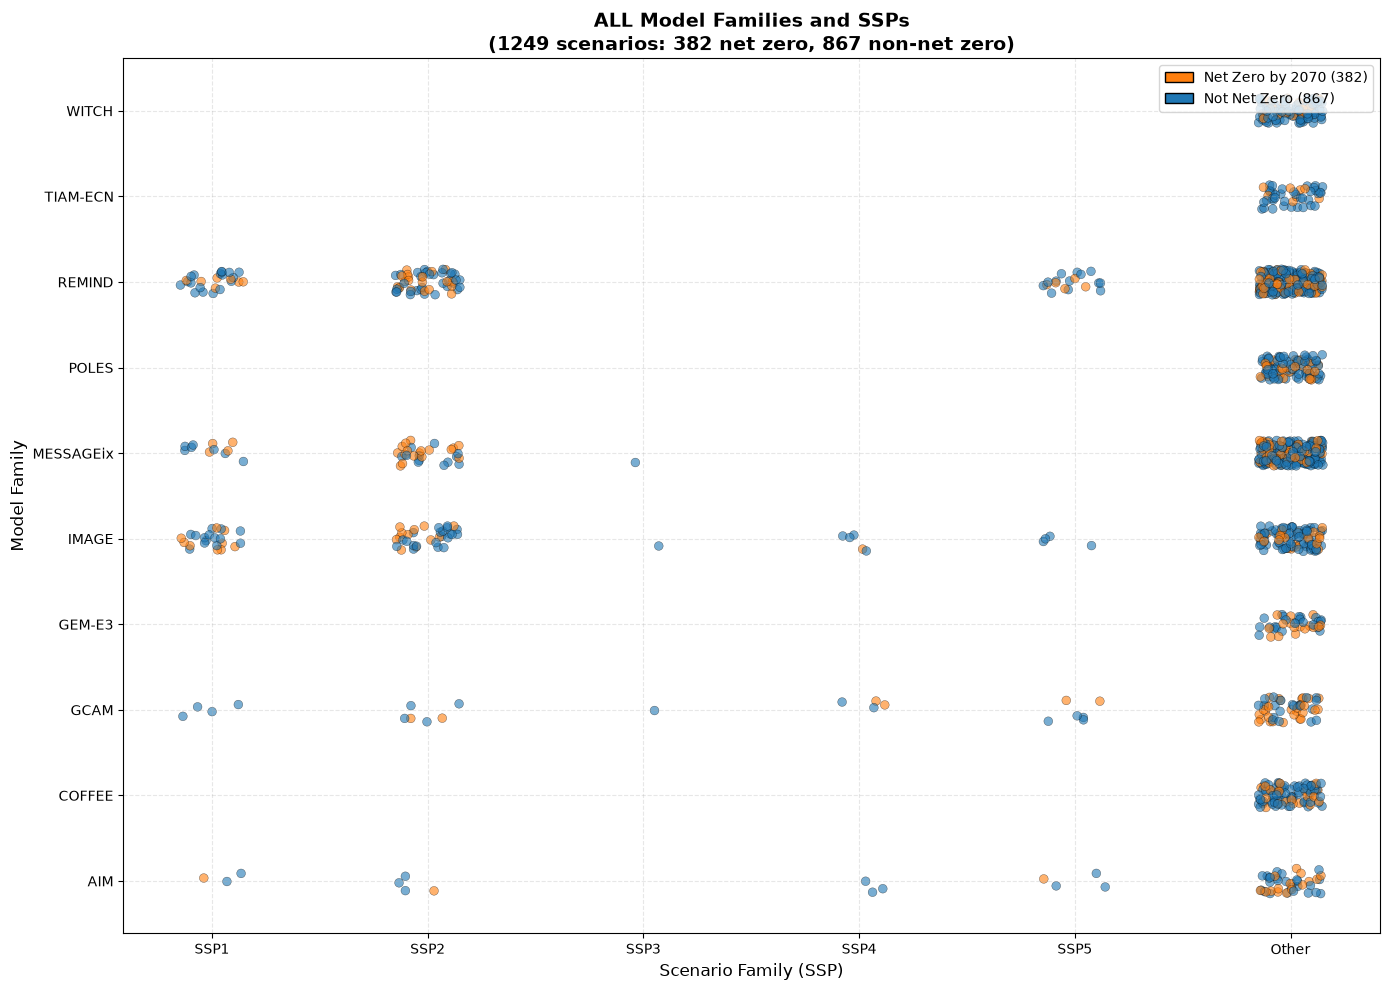

In [69]:
# Visualize all scenarios by Model Family and SSP
fig, ax = plt.subplots(figsize=(14, 10))

# Create numeric encoding for axes
unique_ssps = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5', 'Other']
ssp_to_num = {ssp: i for i, ssp in enumerate(unique_ssps) if ssp in all_data['SSP'].values}
unique_families = sorted(all_data['Model_Family'].unique())
family_to_num = {family: i for i, family in enumerate(unique_families)}

all_data['SSP_Num'] = all_data['SSP'].map(ssp_to_num)
all_data['Family_Num'] = all_data['Model_Family'].map(family_to_num)

# Add jitter to avoid overlapping points
np.random.seed(42)  # For reproducibility
jitter_amount = 0.15
all_data['SSP_Jitter'] = all_data['SSP_Num'] + np.random.uniform(-jitter_amount, jitter_amount, len(all_data))
all_data['Family_Jitter'] = all_data['Family_Num'] + np.random.uniform(-jitter_amount, jitter_amount, len(all_data))

# Plot points colored by net zero status
colors = ['#ff7f0e' if nz else '#1f77b4' for nz in all_data['Net Zero']]
ax.scatter(all_data['SSP_Jitter'], all_data['Family_Jitter'], 
           c=colors, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)

# Customize plot
ax.set_xlabel('Scenario Family (SSP)', fontsize=12)
ax.set_ylabel('Model Family', fontsize=12)
ax.set_xticks(list(ssp_to_num.values()))
ax.set_xticklabels([ssp for ssp in unique_ssps if ssp in ssp_to_num.keys()], fontsize=10)
ax.set_yticks(list(family_to_num.values()))
ax.set_yticklabels(unique_families, fontsize=10)
ax.set_title(f'ALL Model Families and SSPs\n({len(all_data)} scenarios: {all_data["Net Zero"].sum()} net zero, {(~all_data["Net Zero"]).sum()} non-net zero)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff7f0e', edgecolor='black', label=f'Net Zero by 2070 ({all_data["Net Zero"].sum()})'),
    Patch(facecolor='#1f77b4', edgecolor='black', label=f'Not Net Zero ({(~all_data["Net Zero"]).sum()})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

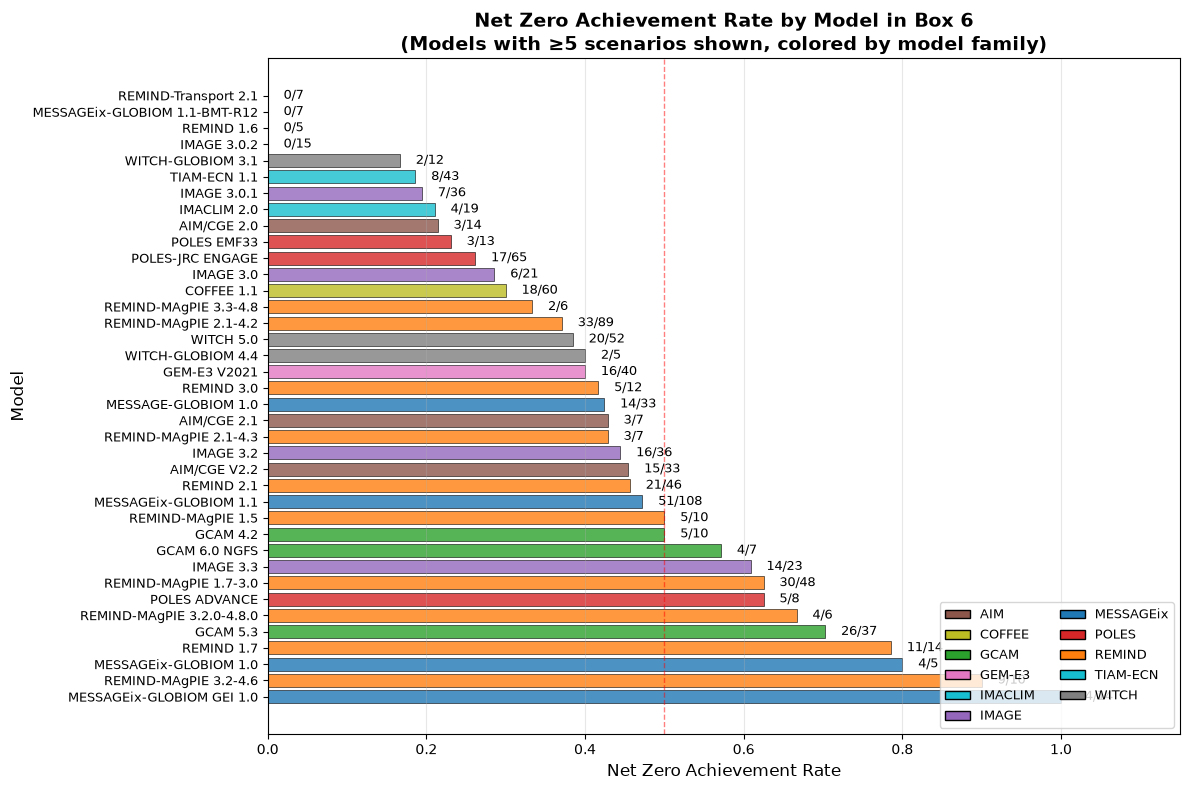

In [54]:
# Bar chart showing net zero rate by model family for scenarios in the box
fig, ax = plt.subplots(figsize=(12, 8))

# Filter to model families with at least 5 scenarios in the box for meaningful statistics
model_summary_filtered = model_summary[model_summary['Total Count'] >= 5].copy()

# Assign colors to model families
unique_families = model_summary_filtered['Model_Family'].unique()
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_families)))
family_colors = dict(zip(unique_families, color_palette))

# Get colors for each bar
bar_colors = [family_colors[family] for family in model_summary_filtered['Model_Family']]

# Create bar chart
bars = ax.barh(range(len(model_summary_filtered)), 
               model_summary_filtered['Net Zero Rate'],
               color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add count labels
for i, (idx, row) in enumerate(model_summary_filtered.iterrows()):
    ax.text(row['Net Zero Rate'] + 0.02, i, 
            f"{int(row['Net Zero Count'])}/{int(row['Total Count'])}", 
            va='center', fontsize=9)

# Customize plot
ax.set_yticks(range(len(model_summary_filtered)))
ax.set_yticklabels(model_summary_filtered['Model_Family'], fontsize=9)
ax.set_xlabel('Net Zero Achievement Rate', fontsize=12)
ax.set_ylabel('Model Family', fontsize=12)
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title(f'Net Zero Achievement Rate by Model Family in Box {selected_box}\n(Model families with ≥5 scenarios shown)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()